In [8]:
import pandas as pd

df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [3]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
719,2023-01-12,33.0,53.0,34.0,"6,566",436.0
718,2023-01-22,32.0,49.0,39.0,"7,122",227.0
717,2023-01-23,32.0,50.0,39.0,"7,280",181.0
716,2023-01-24,47.0,42.0,47.0,"7,433",175.0
715,2023-01-25,20.0,22.0,41.0,"7,538",180.0


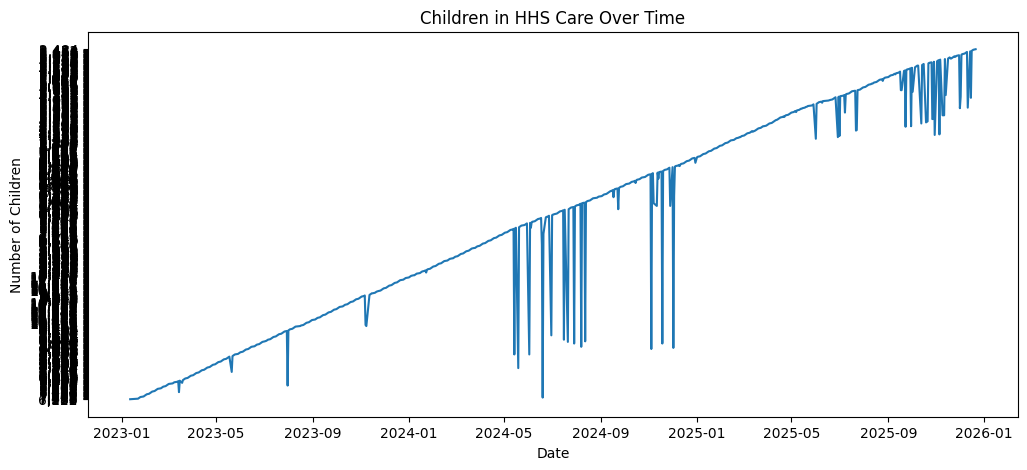

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children in HHS Care'])

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.show()

In [11]:
cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)                      # convert to string
        .str.replace(',', '', regex=True) # remove commas
        .str.strip()                      # remove extra spaces
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert to number

In [12]:
print(df.dtypes)

Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                        int64
Children discharged from HHS Care                         float64
lag_1                                                         str
lag_7                                                         str
dtype: object


In [13]:
df = df.dropna()

In [14]:
df['lag_1'] = df['Children in HHS Care'].shift(1)
df['lag_7'] = df['Children in HHS Care'].shift(7)
df['rolling_mean'] = df['Children in HHS Care'].rolling(7).mean()

df = df.dropna()

In [15]:
features = ['lag_1', 'lag_7', 'rolling_mean']
target = 'Children in HHS Care'

In [16]:
train = df[:-30]   # training data
test = df[-30:]    # last 30 days for testing

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(train[features], train[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
predictions = model.predict(test[features])

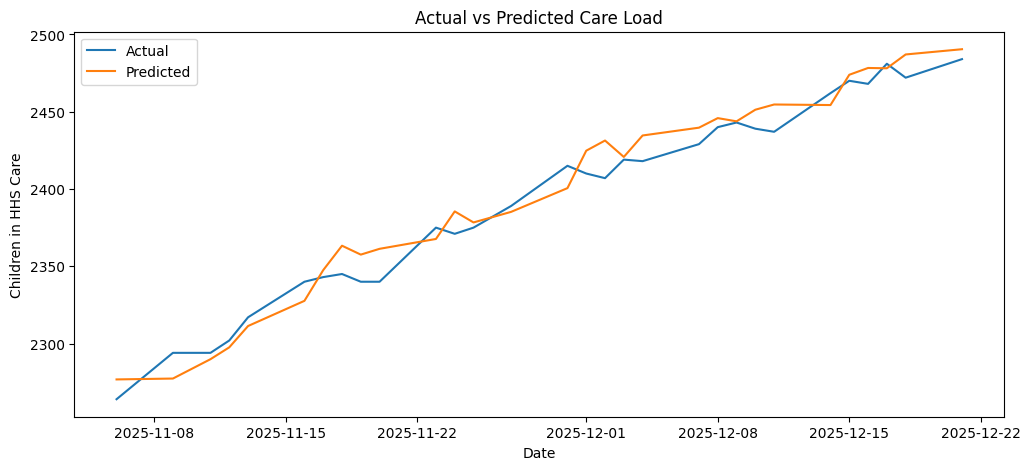

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test['Date'], test[target], label='Actual')
plt.plot(test['Date'], predictions, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Care Load")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test[target], predictions)

print("MAE:", mae)

MAE: 10.397776713285293
